In [3]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict


In [10]:
class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float
    category: str

In [11]:
def label_bmi(state: BMIState) -> BMIState:
    bmi = state["bmi"]
    if bmi < 18.5:
        category = "Underweight"
    elif 18.5 <= bmi < 24.9:
        category = "Normal weight"
    elif 25 <= bmi < 29.9:
        category = "Overweight"
    else:
        category = "Obesity"
    
    state["category"] = category
    return state

In [5]:
def calculate_bmi(state: BMIState) -> BMIState:
    state['bmi'] = round(state['weight'] / (state['height'] ** 2), 2)
    return state

In [12]:
# define the graph
graph = StateGraph(BMIState)
# add nodes to your graph
graph.add_node("calculate_bmi", calculate_bmi)
graph.add_node("label_bmi", label_bmi)
# add edges to your graph
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", "label_bmi")
graph.add_edge("label_bmi", END)
# compile the graph
workflow = graph.compile()

 

In [ ]:
initial_state = {"weight": 80, "height": 1.75, "bmi": 0}
final_state = workflow.invoke(initial_state)
print(final_state)  # Output: {'weight': 80, 'height': 1.75, 'bmi': 26.12, 'category': 'Overweight'}

{'weight': 80, 'height': 1.75, 'bmi': 26.12, 'category': 'Overweight'}


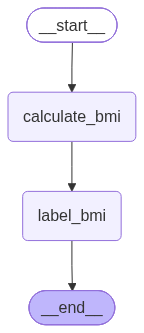

In [13]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())